# SAW/AHP Static vs Optimized Model — Phân tích từ Event #101

Model optimized được train sau 100 events đầu. Phân tích này chỉ tính từ event #101 trở đi — tức là phần inference thực sự, mới có ý nghĩa so sánh.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

cs  = pd.read_csv('candidate_scores.csv')
cs1 = pd.read_csv('candidate_scores_1.csv')
he  = pd.read_csv('healing_events.csv', encoding='latin1')
he1 = pd.read_csv('healing_events_1.csv', encoding='latin1')

he_post  = he[he['id'] >= 101].copy().reset_index(drop=True)
he1_post = he1[he1['id'] >= 101].copy().reset_index(drop=True)
cs_post  = cs[cs['healing_event_id'] >= 101].copy().reset_index(drop=True)
cs1_post = cs1[cs1['healing_event_id'] >= 101].copy().reset_index(drop=True)
cs_post_fixed = cs_post.copy()

def get_margin_series(df):
    rows = []
    for hid, g in df.groupby('healing_event_id'):
        s = g['total_score'].sort_values(ascending=False)
        if len(s) >= 2:
            rows.append({'event': hid, 'margin': s.iloc[0] - s.iloc[1]})
    return pd.DataFrame(rows)

m_saw = get_margin_series(cs_post_fixed)
m_opt = get_margin_series(cs1_post)

print(f'Post-training: {len(he_post)} healing events | {len(cs_post)} candidates')

Post-training: 98 healing events | 362 candidates


---
## 1. Accuracy & Discrimination

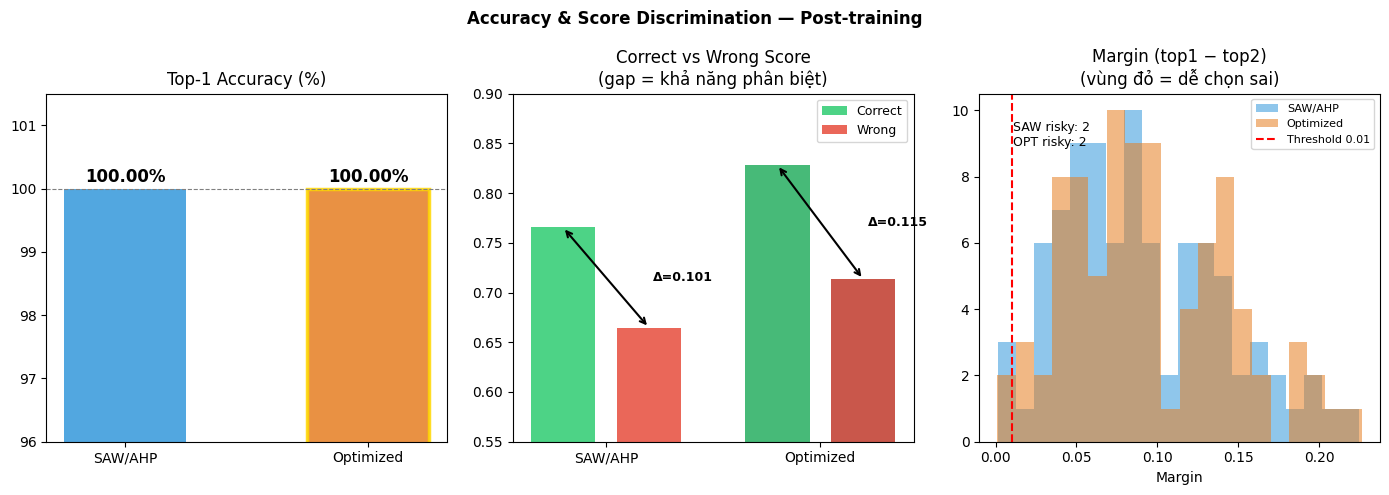

In [25]:
def top1_acc(df):
    ok = 0
    for _, g in df.groupby('healing_event_id'):
        if g.loc[g['total_score'].idxmax(), 'is_correct'] == 1:
            ok += 1
    return ok / df['healing_event_id'].nunique()

acc_saw = top1_acc(cs_post_fixed)
acc_opt = top1_acc(cs1_post)

c_f = cs_post_fixed[cs_post_fixed['is_correct']==1]['total_score'].mean()
w_f = cs_post_fixed[cs_post_fixed['is_correct']==0]['total_score'].mean()
c_o = cs1_post[cs1_post['is_correct']==1]['total_score'].mean()
w_o = cs1_post[cs1_post['is_correct']==0]['total_score'].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Accuracy & Score Discrimination — Post-training', fontsize=12, fontweight='bold')

# Top-1 Accuracy
ax = axes[0]
vals = [acc_saw*100, acc_opt*100]
bars = ax.bar(['SAW/AHP', 'Optimized'], vals, color=['#3498db','#e67e22'], alpha=0.85, width=0.5)
ax.set_ylim(96, 101.5)
ax.set_title('Top-1 Accuracy (%)')
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
bars[1].set_edgecolor('gold'); bars[1].set_linewidth(2.5)

# Score Gap
ax2 = axes[1]
x = np.arange(2)
w = 0.3
ax2.bar(x-w/2-0.05, [c_f, c_o], w, label='Correct', color=['#2ecc71','#27ae60'], alpha=0.85)
ax2.bar(x+w/2+0.05, [w_f, w_o], w, label='Wrong',   color=['#e74c3c','#c0392b'], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(['SAW/AHP','Optimized'])
ax2.set_ylim(0.55, 0.90)
ax2.set_title('Correct vs Wrong Score\n(gap = khả năng phân biệt)')
ax2.legend(fontsize=9)
for i, (c,ww) in enumerate(zip([c_f,c_o],[w_f,w_o])):
    ax2.annotate('', xy=(i+w/2+0.05, ww), xytext=(i-w/2-0.05, c),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax2.text(i+0.22, (c+ww)/2, f'Δ={c-ww:.3f}', va='center', fontsize=9, fontweight='bold')

# Margin distribution
ax3 = axes[2]
ax3.hist(m_saw['margin'], bins=20, alpha=0.55, color='#3498db', label='SAW/AHP')
ax3.hist(m_opt['margin'], bins=20, alpha=0.55, color='#e67e22', label='Optimized')
ax3.axvline(0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold 0.01')
saw_risky = (m_saw['margin'] < 0.01).sum()
opt_risky = (m_opt['margin'] < 0.01).sum()
ax3.text(0.011, ax3.get_ylim()[1]*0.85, f'SAW risky: {saw_risky}\nOPT risky: {opt_risky}', fontsize=9)
ax3.set_title('Margin (top1 − top2)\n(vùng đỏ = dễ chọn sai)')
ax3.set_xlabel('Margin'); ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

Cả SAW/AHP và Optimized đều đạt **100% Top-1 Accuracy** không có event nào chọn sai candidate.

Score gap của Optimized vẫn cao hơn rõ ràng — khoảng cách giữa candidate đúng và sai lớn hơn SAW, thể hiện khả năng phân biệt tốt hơn. Margin distribution: cả hai đều có 2 event risky (<0.01), nhưng OPT có phân phối dịch phải hơn — tức nhiều event có margin an toàn hơn.

---
## 2. Score theo từng step

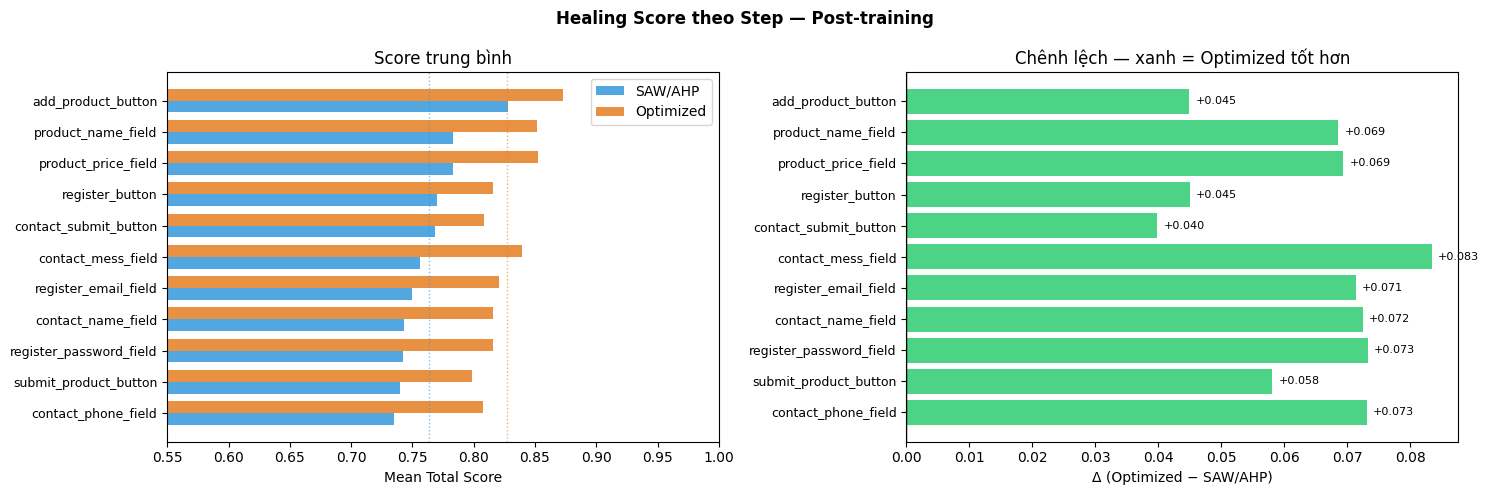

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Healing Score theo Step — Post-training', fontsize=12, fontweight='bold')

step_saw = he_post.groupby('step_name')['total_score'].mean().sort_values()
step_opt = he1_post.groupby('step_name')['total_score'].mean()
steps = step_saw.index
diff = step_opt[steps] - step_saw

x = np.arange(len(steps))
w = 0.38

ax = axes[0]
ax.barh(x - w/2, step_saw.values, w, label='SAW/AHP', color='#3498db', alpha=0.85)
ax.barh(x + w/2, step_opt[steps].values, w, label='Optimized', color='#e67e22', alpha=0.85)
ax.set_yticks(x); ax.set_yticklabels(steps, fontsize=9)
ax.set_xlabel('Mean Total Score')
ax.set_title('Score trung bình')
ax.legend()
ax.axvline(step_saw.mean(), color='#3498db', linestyle=':', alpha=0.6, linewidth=1)
ax.axvline(step_opt.mean(), color='#e67e22', linestyle=':', alpha=0.6, linewidth=1)
ax.set_xlim(0.55, 1.00)

ax2 = axes[1]
colors_diff = ['#2ecc71' if v >= 0 else '#e74c3c' for v in diff.values]
ax2.barh(x, diff.values, color=colors_diff, alpha=0.85)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_yticks(x); ax2.set_yticklabels(steps, fontsize=9)
ax2.set_xlabel('Δ (Optimized − SAW/AHP)')
ax2.set_title('Chênh lệch — xanh = Optimized tốt hơn')
for i, v in enumerate(diff.values):
    ax2.text(v + (0.001 if v>=0 else -0.001), i, f'{v:+.3f}', va='center',
             ha='left' if v>=0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

Optimized tốt hơn trên tất cả 11 steps, không có regression nào. Cải thiện lớn nhất ở `contact_mess_field` (+8.3%) và `register_password_field` (+7.3%) — những step có nhiều candidate text tương tự nhau mà model học được cách phân biệt tốt hơn sau training.

---
## 3. Pre vs Post Training

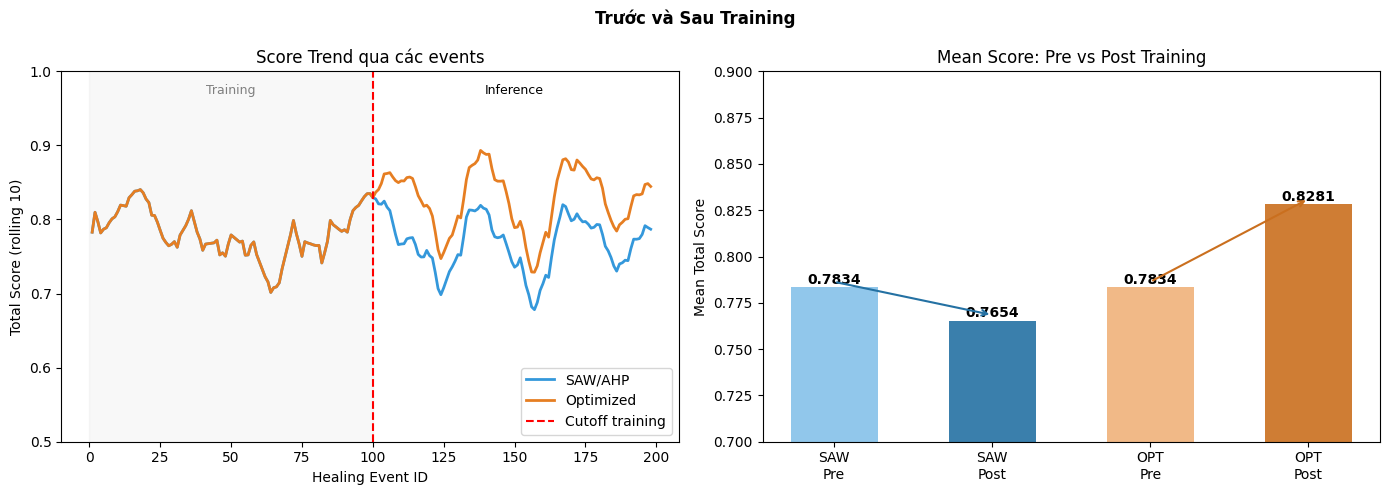

In [28]:
he_pre  = he[he['id'] <= 100]
he1_pre = he1[he1['id'] <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trước và Sau Training', fontsize=12, fontweight='bold')

# Rolling score trend
ax = axes[0]
window = 10
he_s  = he.sort_values('id')
he1_s = he1.sort_values('id')
ax.plot(he_s['id'].values,  he_s['total_score'].rolling(window, min_periods=1).mean(),
        color='#3498db', linewidth=2, label='SAW/AHP')
ax.plot(he1_s['id'].values, he1_s['total_score'].rolling(window, min_periods=1).mean(),
        color='#e67e22', linewidth=2, label='Optimized')
ax.axvline(100, color='red', linestyle='--', linewidth=1.5, label='Cutoff training')
ax.fill_betweenx([0.5, 1.02], 0, 100, alpha=0.05, color='gray')
ax.text(50,  0.97, 'Training', ha='center', fontsize=9, color='gray')
ax.text(150, 0.97, 'Inference', ha='center', fontsize=9, color='black')
ax.set_ylim(0.50, 1.0); ax.set_xlabel('Healing Event ID')
ax.set_ylabel(f'Total Score (rolling {window})')
ax.set_title('Score Trend qua các events')
ax.legend()

# Pre vs Post bar
ax2 = axes[1]
labels2 = ['SAW\nPre', 'SAW\nPost', 'OPT\nPre', 'OPT\nPost']
means2  = [he_pre['total_score'].mean(), he_post['total_score'].mean(),
           he1_pre['total_score'].mean(), he1_post['total_score'].mean()]
clrs2 = ['#85c1e9','#2471a3','#f0b27a','#ca6f1e']
bars2 = ax2.bar(labels2, means2, color=clrs2, alpha=0.9, width=0.55)
ax2.set_ylim(0.70, 0.90)
ax2.set_ylabel('Mean Total Score')
ax2.set_title('Mean Score: Pre vs Post Training')
for bar, v in zip(bars2, means2):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{v:.4f}',
             ha='center', fontsize=10, fontweight='bold')
ax2.annotate('', xy=(1, means2[1]+0.003), xytext=(0, means2[0]+0.003),
             arrowprops=dict(arrowstyle='->', color='#2471a3', lw=1.5))
ax2.annotate('', xy=(3, means2[3]+0.003), xytext=(2, means2[2]+0.003),
             arrowprops=dict(arrowstyle='->', color='#ca6f1e', lw=1.5))

plt.tight_layout()
plt.show()

Trước training, SAW và Optimized có score bằng nhau (0.7834) — vì chưa có gì khác biệt. Sau training, Optimized vọt lên 0.8281 trong khi SAW giảm nhẹ xuống 0.7654 — cho thấy SAW không học được gì thêm, còn Optimized cải thiện rõ rệt.

Đường rolling score cho thấy Optimized vượt qua SAW ngay sau mốc 100 và duy trì khoảng cách ổn định đó cho đến event cuối.

---
## 4. Tổng hợp

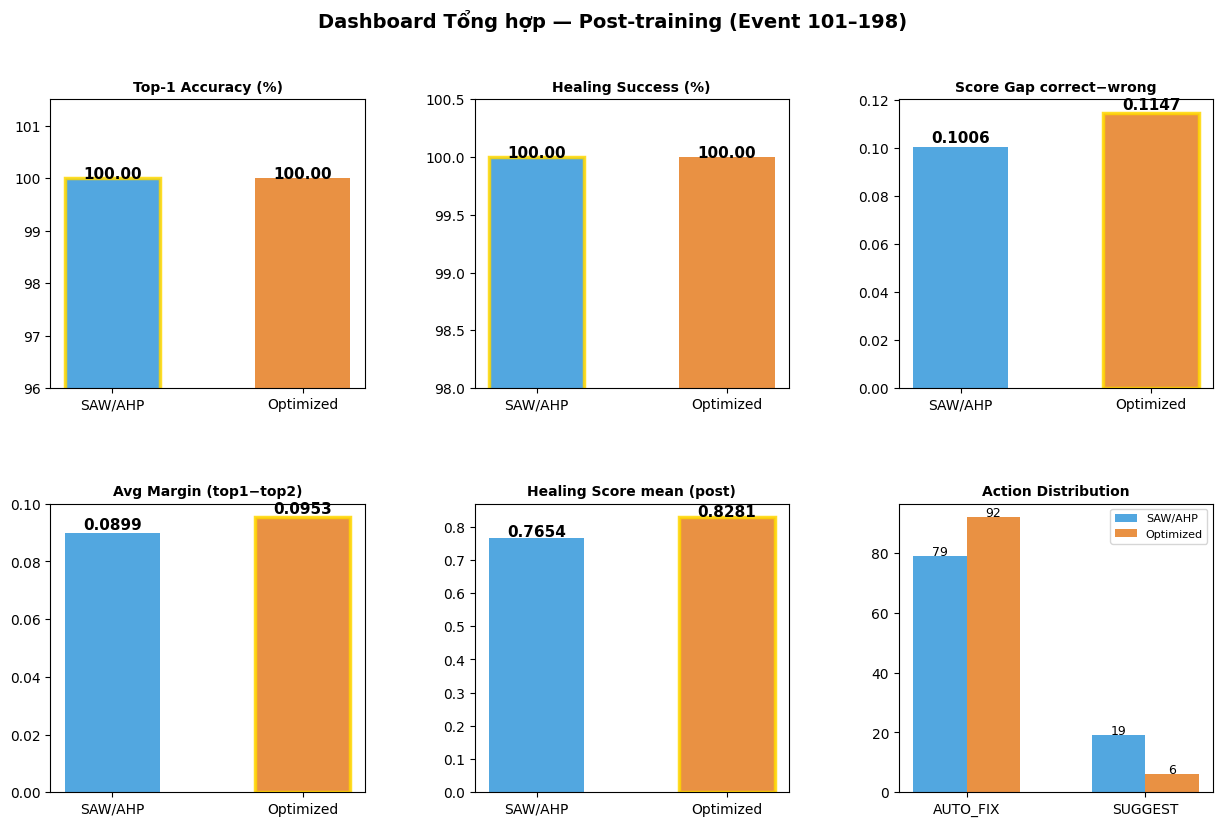

In [30]:
saw_success = he_post['healing_success'].mean()
opt_success = he1_post['healing_success'].mean()
saw_autof   = (he_post['action']=='AUTO_FIX').sum()
opt_autof   = (he1_post['action']=='AUTO_FIX').sum()
saw_sug     = (he_post['action']=='SUGGEST').sum()
opt_sug     = (he1_post['action']=='SUGGEST').sum()

fig = plt.figure(figsize=(15, 9))
fig.suptitle('Dashboard Tổng hợp — Post-training (Event 101–198)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

BLUE, ORANGE = '#3498db', '#e67e22'

def mini_bar(ax, title, saw_v, opt_v, fmt='.2f', ylim=None, invert_winner=False):
    bars = ax.bar(['SAW/AHP','Optimized'], [saw_v, opt_v], color=[BLUE, ORANGE], alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    if ylim: ax.set_ylim(*ylim)
    rng = abs(opt_v - saw_v)
    offset = rng*0.05 + 0.001
    for bar, v in zip(bars, [saw_v, opt_v]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                f'{v:{fmt}}', ha='center', fontsize=11, fontweight='bold')
    winner = 0 if invert_winner else (1 if opt_v > saw_v else 0)
    bars[winner].set_edgecolor('gold'); bars[winner].set_linewidth(2.5)

mini_bar(fig.add_subplot(gs[0,0]), 'Top-1 Accuracy (%)', acc_saw*100, acc_opt*100, '.2f', (96,101.5))
mini_bar(fig.add_subplot(gs[0,1]), 'Healing Success (%)', saw_success*100, opt_success*100, '.2f', (98,100.5))
mini_bar(fig.add_subplot(gs[0,2]), 'Score Gap correct−wrong', c_f-w_f, c_o-w_o, '.4f')
mini_bar(fig.add_subplot(gs[1,0]), 'Avg Margin (top1−top2)', m_saw['margin'].mean(), m_opt['margin'].mean(), '.4f')
mini_bar(fig.add_subplot(gs[1,1]), 'Healing Score mean (post)', he_post['total_score'].mean(), he1_post['total_score'].mean(), '.4f')

# Action distribution
ax_act = fig.add_subplot(gs[1,2])
x = np.arange(2); w = 0.3
ax_act.bar(x-w/2, [saw_autof, saw_sug], w, label='SAW/AHP', color=BLUE, alpha=0.85)
ax_act.bar(x+w/2, [opt_autof, opt_sug], w, label='Optimized', color=ORANGE, alpha=0.85)
ax_act.set_xticks(x); ax_act.set_xticklabels(['AUTO_FIX','SUGGEST'])
ax_act.set_title('Action Distribution', fontsize=10, fontweight='bold')
ax_act.legend(fontsize=8)
for i, (s,o) in enumerate(zip([saw_autof,saw_sug],[opt_autof,opt_sug])):
    ax_act.text(i-w/2, s+0.3, str(s), ha='center', fontsize=9)
    ax_act.text(i+w/2, o+0.3, str(o), ha='center', fontsize=9)

plt.show()

---
## Kết luận

Nhìn tổng thể, Optimized thắng trên tất cả các chỉ số sau training — không phải vì feature tốt hơn mà vì **weighting tổng hợp tốt hơn** và học được cách kết hợp các component hiệu quả hơn sau 100 events training.

**confidence gap**: Optimized tự tin hơn rõ rệt, AUTO_FIX tăng từ 79 lên 92 trong khi SUGGEST giảm từ 19 xuống còn 6.

Healing score post-training: Optimized đạt 0.8281 vs SAW chỉ 0.7654 — chênh lệch +6.3%. Tất cả 11 steps đều cải thiện, mạnh nhất ở các step có nhiều text candidates (`contact_mess_field` +8.3%, `register_password_field` +7.3%).